In [ ]:
!pip install -q ucimlrepo xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [ ]:
phiusiil = fetch_ucirepo(id=967)

X = phiusiil.data.features
y = phiusiil.data.targets

print(X.shape)
print(y.shape)

(235795, 54)
(235795, 1)


In [ ]:
df = pd.concat([X, y], axis=1)

print(df.shape)

df.head()

(235795, 55)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
X = X.copy()

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
y = y.iloc[:,0]

if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(188636, 54)
(47159, 54)


MODEL 1 - DECISION TREE

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]

In [ ]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

print("Decision Tree Results")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

Decision Tree Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


In [ ]:
dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[20189     0]
 [    0 26970]]


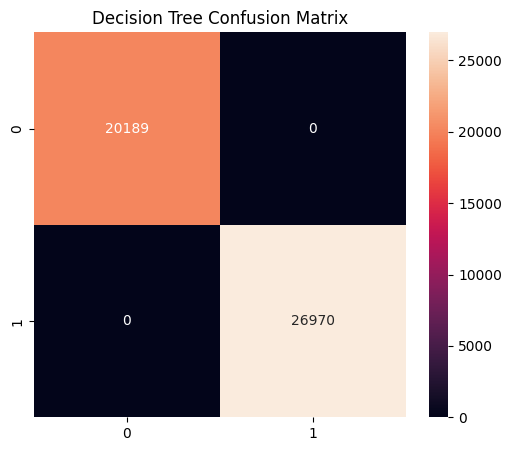

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d'
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

MODEL 2 - RANDOM FOREST

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Random Forest Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[20189     0]
 [    0 26970]]


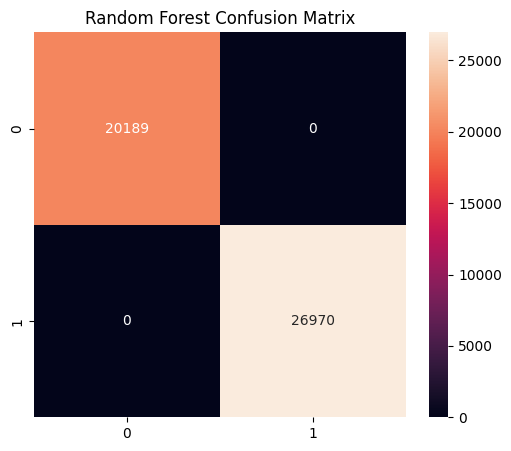

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")
plt.show()

MODEL 3 - XGBOOST (YOUR PROPOSED MODEL)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Results")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_auc)

XGBoost Results
Accuracy : 0.999978795139846
Precision: 0.9999629231396685
Recall   : 1.0
F1 Score : 0.9999814612261545
ROC-AUC  : 1.0


In [ ]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

print(xgb_cm)

[[20188     1]
 [    0 26970]]


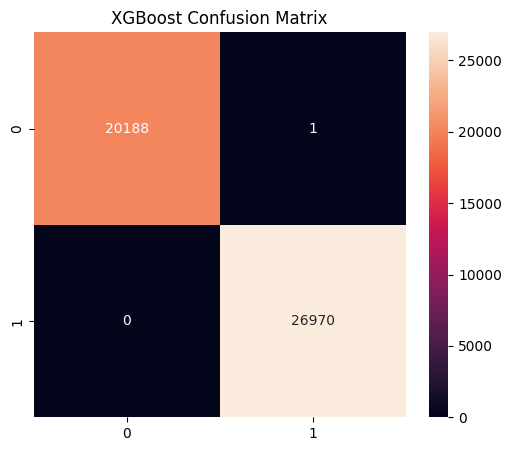

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d'
)

plt.title("XGBoost Confusion Matrix")
plt.show()

ROC CURVE COMPARISON

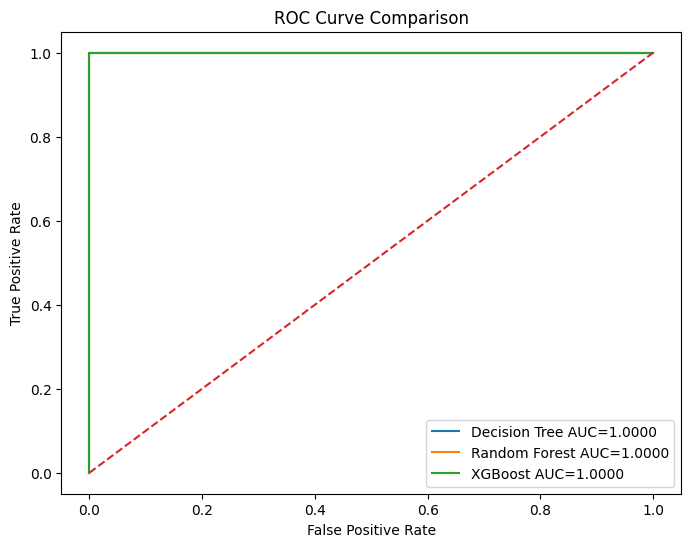

In [ ]:
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree AUC={dt_auc:.4f}"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC={rf_auc:.4f}"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost AUC={xgb_auc:.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

FINAL COMPARISON TABLE

In [ ]:
results = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision":[
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall":[
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score":[
        dt_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC":[
        dt_auc,
        rf_auc,
        xgb_auc
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0,1.0,1.0


BEST MODEL

In [ ]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Model")

print(best_model)

Best Model
Model        Decision Tree
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1 Score               1.0
ROC-AUC                1.0
Name: 0, dtype: object


In [ ]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0,1.0,1.0


In [ ]:
print(X.columns.tolist())

['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [ ]:
for col in X.columns:
    print(col)

URL
URLLength
Domain
DomainLength
IsDomainIP
TLD
URLSimilarityIndex
CharContinuationRate
TLDLegitimateProb
URLCharProb
TLDLength
NoOfSubDomain
HasObfuscation
NoOfObfuscatedChar
ObfuscationRatio
NoOfLettersInURL
LetterRatioInURL
NoOfDegitsInURL
DegitRatioInURL
NoOfEqualsInURL
NoOfQMarkInURL
NoOfAmpersandInURL
NoOfOtherSpecialCharsInURL
SpacialCharRatioInURL
IsHTTPS
LineOfCode
LargestLineLength
HasTitle
Title
DomainTitleMatchScore
URLTitleMatchScore
HasFavicon
Robots
IsResponsive
NoOfURLRedirect
NoOfSelfRedirect
HasDescription
NoOfPopup
NoOfiFrame
HasExternalFormSubmit
HasSocialNet
HasSubmitButton
HasHiddenFields
HasPasswordField
Bank
Pay
Crypto
HasCopyrightInfo
NoOfImage
NoOfCSS
NoOfJS
NoOfSelfRef
NoOfEmptyRef
NoOfExternalRef


In [ ]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(235795, 54)
(235795,)
label
1    134850
0    100945
Name: count, dtype: int64
